# Spatial network analysis

Contents:
- Why do spatial network analysis?
- Retrieving a street network from OpenStreetMap
- Preparing the network for routing (adding travel time)
- Building a routable graph
- Finding the shortest path:
  - From A to B (by distance and by travel time)
  - One-way streets and the direction of travel
  - From one origin to many destinations (a first look at accessibility; see Chapter 11)
- Other uses of networks (brief pointer) — common network operations such as connected components and centrality are covered in Chapter 8.3


This section focuses on spatial networks and learning how to construct a routable directed graph for `networkx` library that can be used to find a shortest paths along the given street network based on travel times or distance by given transport mode (e.g. car or cycling). Finding a shortest path from A to B using a specific street network is a very common problem in GIS that has many practical applications. For example, navigation services use shortest path analysis to guide drivers, cyclists and pedestrians to their destination, emergency services use it to estimate how quickly an ambulance can reach a given address, and delivery companies use it to plan their routes. Network analysis is also commonly used in urban planning, for instance to study how easily people can reach services such as schools, health care or grocery stores (a topic that we return to in Chapter 11).

Python provides easy to use tools for conducting spatial network analysis. One of the easiest ways to start is to use a library called `networkx`[^networkx]
which is a Python module that provides a lot tools that can be used to analyze networks on various different ways. It also contains algorithms such as Dijkstra’s algorithm[^dijkstra] or A\*[^astar]
algorithm that are commonly used to find shortest paths along transportation network that can help e.g. in wayfinding.

## Typical workflow for routing

If you want to conduct network analysis (in any programming language) there are a few basic steps that typically needs to be done before you can start routing. These steps are:

 1. **Retrieve data** (such as street network from OSM or Digiroad + possibly transit data if routing with PT).
 2. **Modify the network** by adding/calculating edge weights (such as travel times based on speed limit and length of the road segment).
 3. **Build a routable graph** for the routing tool that you are using (e.g. for NetworkX, igraph or OpenTripPlanner).
 4. **Conduct network analysis** (such as shortest path analysis) with the routing tool of your choice.

## Retrieving network data

As a first step, we need to obtain data for routing. `osmnx`[^osmnx] library makes it really easy to retrieve routable networks from OpenStreetMap (OSM) with different transport modes (walking, cycling and driving). 

Let's first extract OSM data for Helsinki city centre that are drivable by car. In `osmnx`, we can use a function called `ox.graph_from_point()` which retrieves data from OpenStreetMap around a given center point. We define the center point as a `(latitude, longitude)` pair and set how far around it to fetch data with the `dist` parameter (in meters). It is possible to specify what kind of roads should be retrieved from OSM with `network_type` -parameter (supports e.g. `walk`, `drive`, `bike`, `all`). In the following, we fetch all the drivable roads around the Helsinki city centre:

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import networkx as nx

# The area of interest
center_point = (60.162, 24.937)

G = ox.graph_from_point(center_point, dist=2500, network_type="drive", simplify=False)

type(G)

networkx.classes.multidigraph.MultiDiGraph

Okay, as we can see we have now fetched a routable graph out of OpenStreetMap data of ours which is something called `MultiDiGraph` object of `networkx` library.

So basically this graph `G` is made out of **nodes** and **edges**. We can easily extract the `nodes` and `edges` out of this graph by using `osmnx` as follows: 

In [2]:
# Extract the nodes and edges
nodes, edges = ox.graph_to_gdfs(G)
edges.head()

,,,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,ref,bridge,width,junction,access,tunnel,est_width,geometry
u,v,key,,,,,,,,,,,,,,,,
24556474,575256449,0,22963794,residential,2,30,Merikannontie,False,True,63.929759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (24.90963 60.18386, 24.91014 60.18335)"
25198796,1647834607,0,17482188,motorway,3,80,Länsiväylä,True,False,37.660749,51,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (24.90065 60.16698, 24.90133 60.16702)"
25198805,1519479211,0,331102263,motorway,4,80,Länsiväylä,True,False,37.724304,51,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (24.9032 60.16705, 24.90388 60.16703)"
25198815,1004300273,0,78710031,motorway,2,80,Länsiväylä,True,False,34.566048,51,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (24.90869 60.16657, 24.90811 60.16668)"
25198820,1004300316,0,78710037,motorway,4,80,Länsiväylä,True,False,41.361762,51,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (24.90803 60.16657, 24.90871 60.16642)"


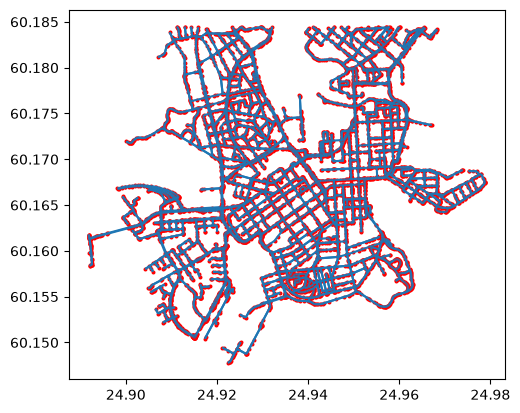

In [3]:
ax = edges.plot()
ax = nodes.plot(ax=ax, color="red", markersize=3.5)

_**Figure 8.X.** Drivable streets (edges) and their nodes (in red) in the Helsinki city centre, retrieved from OpenStreetMap._

Okay, now we have drivable roads as a GeoDataFrame for the Helsinki city centre. If you look at the GeoDataFrame, we can see that `osmnx` has also calculated us the `length` of each road segment (presented in meters). The geometries are presented here as `LineString` objects. Notice that when calculating length yourself, it is important that your input data is in projected coordinate system. In case your data has e.g. `WGS84` as the CRS (like the data we retrieved from OpenStreetMap), you should first reproject your data into an appropriate metric system (see Chapter 6.4). In OSM, the information about the allowed direction of movement is stored in column `oneway`. Let's take a look what kind of values we have in that column:

In [4]:
edges["oneway"].unique()

array([False,  True])

As we can see the unique values in that column are `True` and `False`. This information can be used to construct a `directed` graph for routing by car. For walking and cycling, you typically want create a `bidirectional` graph, because the travel is typically allowed in both directions at least in Finland. Notice, that the rules vary by country, e.g. in Copenhagen you have oneway rules also for bikes but typically each road have the possibility to travel both directions (you just need to change the side of the road if you want to make a U-turn). Column `maxspeed` contains information about the speed limit for given road:

In [5]:
edges["maxspeed"].unique()

<ArrowStringArray>
['30', '80', '60', '50', '40', nan, '20', '10']
Length: 8, dtype: str

As we can see, there are also `None` values in the data, meaning that the speed limit has not been tagged for some roads. This is typical, and often you need to fill the non existing speed limits yourself. This can be done by taking advantage of the road class that is always present in column `highway`:

In [6]:
edges["highway"].unique()

<ArrowStringArray>
[  'residential',      'motorway',     'secondary', 'motorway_link',
       'primary',      'tertiary',  'unclassified', 'living_street',
 'tertiary_link',  'primary_link']
Length: 10, dtype: str

Based on these values, we can make assumptions that e.g. `living_street` roads in Helsinki have a speed limit of 20 kmph. Hence, this information can be used to fill the missing values in `maxspeed`. The second dataset that we extracted from the graph are `nodes`:

In [7]:
nodes.head()

,y,x,street_count,highway,railway,junction,ref,geometry
osmid,,,,,,,,
24556474,60.183861,24.909628,2,NaN,NaN,NaN,NaN,POINT (24.90963 60.18386)
25198796,60.166977,24.900650,2,NaN,NaN,NaN,NaN,POINT (24.90065 60.16698)
25198805,60.167048,24.903203,2,NaN,NaN,NaN,NaN,POINT (24.9032 60.16705)
25198815,60.166565,24.908692,2,NaN,NaN,NaN,NaN,POINT (24.90869 60.16657)
25198820,60.166574,24.908026,2,NaN,NaN,NaN,NaN,POINT (24.90803 60.16657)


As we can see, the `nodes` GeoDataFrame contains information about the coordinates of each node as well as a unique `id` for each node. These `id` values are used to determine the connectivity in our network. Hence, `osmnx` has also stored the **from** and **to** ids for each edge in the index of the `edges` GeoDataFrame (see the output of `edges.head()` above). Index level `u` contains information about the **from-id** and level `v` about the **to-id** accordingly. The third index level, `key`, is used to separate several edges that connect the same pair of nodes.

Okay, as we can see now we have both the roads (i.e. *edges*) and the nodes that connect the street elements together (in red color in the previous figure) that are typically intersections. However, we can see that many of the nodes are in locations that are clearly not intersections. This is intented behavior to ensure that we have full **connectivity** in our network. We can at later stage clean and simplify this network by merging all roads that belong to the same link (i.e. street elements that are between two intersections) which also reduces the size of the network. 

Notice that in OSM, the street topology is typically not directly suitable for graph traversal due to missing nodes at intersections which means that the roads are not splitted at those locations. The consequence of this, is that it is not possible to make a turn if there is no intersection present in the data structure. Hence, `osmnx` will separate all road segments/geometries into individual rows in the data. 


## Modifying the network

At this stage, we have the necessary components to build a routable graph (nodes and edges) based on distance. However, in real life the network distance is not the best cost metric to use, because the shortest path (based on distance) is not necessarily always the optimal route in terms of **travel time**. Time is typically the measure that people value more (plus it is easier to comprehend), so at this stage we want to **add a new cost attribute** to our edges GeoDataFrame that converts the metric distance information to travel time (in seconds) based on following formula:

 - `<distance-in-meters> / (<speed-limit-kmph> / 3.6)`
 
Before we can do this calculation, we need to ensure that all rows in `maxspeed` column have information about the speed limit. Let's check the value counts of the column and also include information about the `NaN` values with `dropna` parameter:

In [8]:
# Count values
edges["maxspeed"].value_counts(dropna=False)

maxspeed
30     13592
40      2629
NaN      740
50       253
20       250
80        56
60         8
10         8
Name: count, dtype: int64

As we can see, the rows which do not contain information about the speed limit is the second largest group in our data. Hence, we need to apply a criteria to fill these gaps. We can do this based on following "rule of thumb" criteria in Finland (notice that these vary country by country):

| Road class           | Speed limit within urban region | Speed limit outside urban region |
|----------------------|---------------------------------|----------------------------------|
| motorway             | 100                             | 120                              |
| motorway_link        | 80                              | 80                               |
| trunk                | 60                              | 100                              |
| trunk_link           | 60                              | 60                               |
| primary              | 50                              | 80                               |
| primary_link         | 50                              | 50                               |
| secondary            | 50                              | 50                               |
| secondary_link       | 50                              | 50                               |
| tertiary             | 50                              | 60                               |
| tertiary_link        | 50                              | 50                               |
| unclassified         | 50                              | 80                               |
| unclassified_link    | 50                              | 50                               |
| residential          | 50                              | 80                               |
| living_street        | 20                              | NA                               |
| service              | 30                              | NA                               |
| other                | 50                              | 80                               |

For simplicity, we can consider that all the roads in Helsinki Region follows the *within urban region* speed limits, although this is not exactly true (the higher speed limits start somewhere at the outer parts of the city region). For making the speed limit values more robust / correct, you could use data about urban/rural classification which is available in Finland from Finnish Environment Institute[^ykr]. Let's first convert our `maxspeed` values to integers using `astype()` method:

In [9]:
edges["maxspeed"] = edges["maxspeed"].astype(float).astype(pd.Int64Dtype())
edges["maxspeed"].unique()

<IntegerArray>
[30, 80, 60, 50, 40, <NA>, 20, 10]
Length: 8, dtype: Int64

As we can see, now the maxspeed values are stored in integer format inside an `IntegerArray`, and the `None` values were converted into `pandas.NA` objects that are assigned with `<NA>`. Now we can create a function that returns a numeric value for different road classes based on the criteria in the table above:

In [10]:
def road_class_to_kmph(road_class):
    """
    Returns a speed limit value based on road class, 
    using typical Finnish speed limit values within urban regions.
    """
    if road_class == "motorway":
        return 100
    elif road_class == "motorway_link":
        return 80
    elif road_class in ["trunk", "trunk_link"]:
        return 60
    elif road_class == "service":
        return 30
    elif road_class == "living_street":
        return 20
    else:
        return 50

Now we can apply this function to all rows that **do not have speed limit information**:

In [11]:
mask = edges["maxspeed"].isnull()

In [12]:
mask

u            v           key
24556474     575256449   0      False
25198796     1647834607  0      False
25198805     1519479211  0      False
25198815     1004300273  0      False
25198820     1004300316  0      False
                                ...  
14180584757  7772108692  0      False
14182283099  1016087546  0      False
             878495745   0      False
14203076514  865311358   0      False
14228197411  1458153326  0      False
Name: maxspeed, Length: 17536, dtype: bool

In [13]:
# Separate rows with / without speed limit information 
mask = edges["maxspeed"].isnull()
edges_without_maxspeed = edges.loc[mask].copy()
edges_with_maxspeed = edges.loc[~mask].copy()

# Apply the function and update the maxspeed
edges_without_maxspeed["maxspeed"] = edges_without_maxspeed["highway"].apply(road_class_to_kmph)
edges_without_maxspeed.head(5).loc[:, ["maxspeed", "highway"]]

maxspeed        highway
u        v           key                         
25290826 3190376686  0          20  living_street
25345643 11763801121 0          50   unclassified
         11763765815 0          50       tertiary
25413456 1009801587  0          50   unclassified
30556091 266179861   0          50   unclassified

Okay, as we can see now the `maxspeed` value have been updated according our criteria, and e.g. the `living_street` road class have been given the speed limit 20 kmph. Now we can recreate the edges GeoDataFrame by combining the two frames: 

In [14]:
edges = pd.concat([edges_with_maxspeed, edges_without_maxspeed])
edges["maxspeed"].unique()

<IntegerArray>
[30, 80, 60, 50, 40, 20, 10]
Length: 7, dtype: Int64

Great, now all of our edges have information about the speed limit. We can also visualize them:

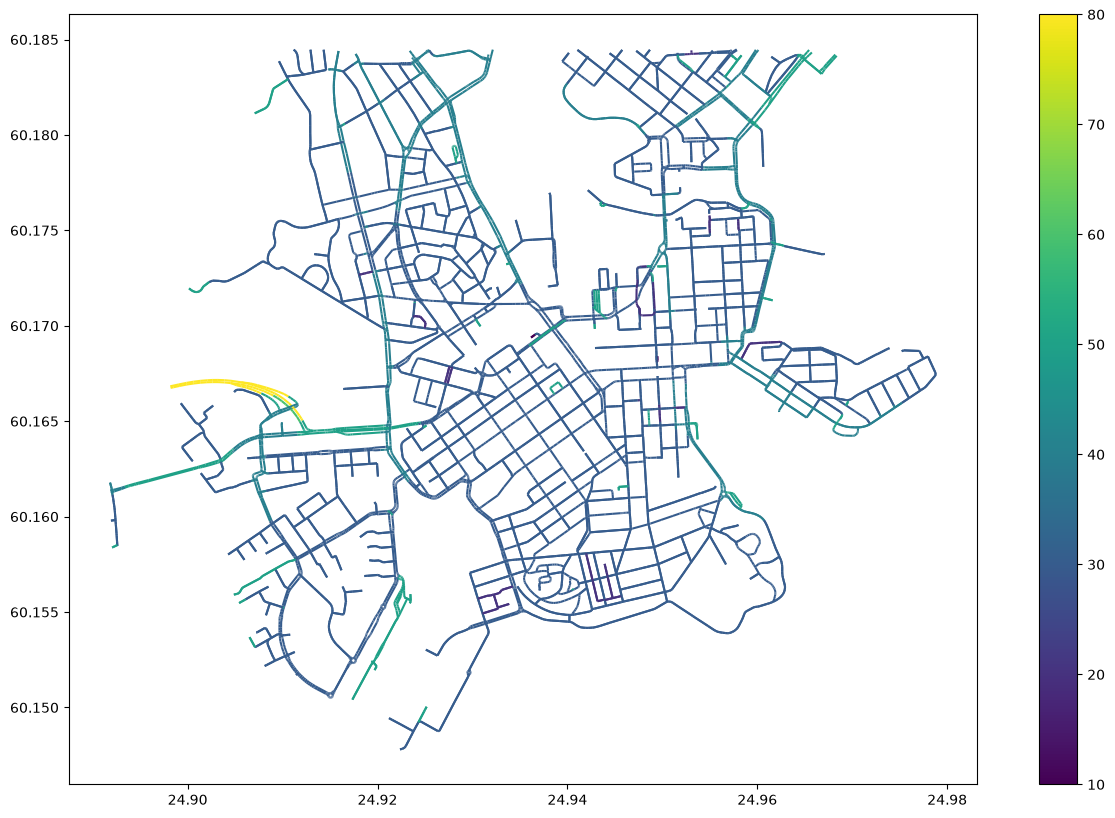

In [15]:
# Convert the value into regular integer Series (the plotting requires having Series instead of IntegerArray) 
edges["maxspeed"] = edges["maxspeed"].astype(int)
ax = edges.plot(column="maxspeed", figsize=(16,10), legend=True)

_**Figure 8.X.** Speed limits (km/h) of the streets after filling in the missing values._

We will calculate the travel time it takes to cross a given street segment assuming that the person would be driving according the speed limits. The `maxspeed` column in our data provides information about the speed limit (km per hour) on a given street element. This is very useful information as we can use this to calculate the "free-flow" travel time which indicates the time it takes to cross a specific street segment assuming that a given person would be able to travel as fast as the speed limit allows.

Now we have all the information needed to calculate the free-flow travel time. To calculate the travel time in seconds, we can use a following formula that considers the speed limit information in km/h and the distance as meters (which is how our data is constructed):

$$
t = \frac{3.6 \, d}{v}
$$

Where:  

- \(t\) = travel time in **seconds (s)**  
- \(d\) = distance in **meters (m)**  
- \(v\) = speed limit in **kilometers per hour (km/h)**

The multiplication of distance by 3.6 is a conversion factor between meters per second and kilometers per hour:

$$
1 \ \text{m/s} = \frac{3600}{1000} \ \text{km/h} = 3.6 \ \text{km/h}
$$


Finally, we can calculate the travel time in seconds using the formula above and add that as a new cost attribute for our network:

In [16]:
edges["travel_time_seconds"] = edges["length"] / (edges["maxspeed"]/3.6)
edges.iloc[0:10, -4:]

,,,tunnel,est_width,geometry,travel_time_seconds
u,v,key,,,,
24556474,575256449,0,NaN,NaN,"LINESTRING (24.90963 60.18386, 24.91014 60.18335)",7.671571
25198796,1647834607,0,NaN,NaN,"LINESTRING (24.90065 60.16698, 24.90133 60.16702)",1.694734
25198805,1519479211,0,NaN,NaN,"LINESTRING (24.9032 60.16705, 24.90388 60.16703)",1.697594
25198815,1004300273,0,NaN,NaN,"LINESTRING (24.90869 60.16657, 24.90811 60.16668)",1.555472
25198820,1004300316,0,NaN,NaN,"LINESTRING (24.90803 60.16657, 24.90871 60.16642)",1.861279
25198822,1004300397,0,NaN,NaN,"LINESTRING (24.91064 60.16595, 24.91012 60.16616)",1.668523
25198825,268724419,0,NaN,NaN,"LINESTRING (24.91032 60.16589, 24.91072 60.16571)",1.782035
25198868,25198879,0,NaN,NaN,"LINESTRING (24.91197 60.16485, 24.91223 60.16456)",2.504486
25198879,269904875,0,NaN,NaN,"LINESTRING (24.91223 60.16456, 24.91227 60.16452)",0.394090


Excellent! Now our GeoDataFrame has all the information we need for creating a graph that can be used to conduct shortest path analysis based on length or travel time. Notice that here we assume that the cars can drive with the same speed as what the speed limit is. Considering the urban dynamics and traffic congestion, this assumption might not hold, but for simplicity, we assume so in this tutorial. 

### Building a routable graph from modified edges

We can use `osmnx` library to easily build a directed graph. Let's see how we can create a routable NetworkX graph using `osmnx` with one command:

In [17]:
G = ox.graph_from_gdfs(gdf_nodes=nodes, gdf_edges=edges)
G

Now we have a similar routable graph as in the beginning, but now the network edges contain information about the speed limit and the travel time (`travel_time_seconds`) for all edges, which we can use as the cost when finding routes. We can easily visualize the graph with `osmnx` as follows: 

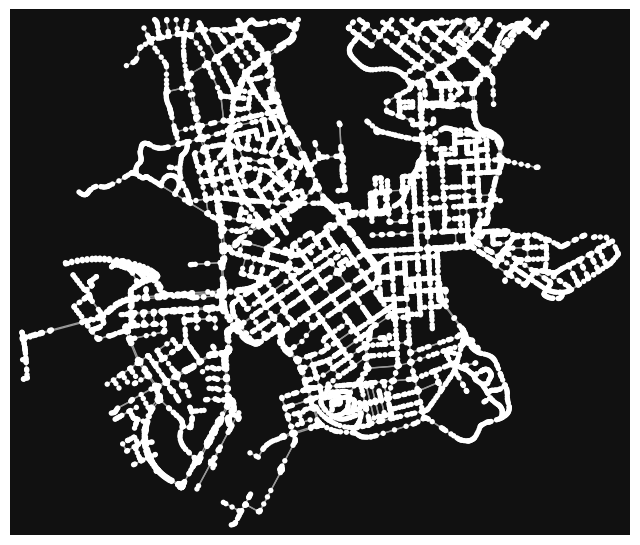

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [18]:
import osmnx as ox 
ox.plot_graph(G)

_**Figure 8.X.** The routable street network of the Helsinki city centre plotted with `osmnx`._

## Shortest path analysis 

Now we have everything we need to start routing with NetworkX (based on driving distance or travel time). One of most widely used real-world use-cases for spatial networks relates to navigation, i.e. how to find a route from a given origin location to a given destination that would be as short (or quick) as possible. There are various approaches and algorithms that allows to find such routes, but the one we introduce here is one of the most famous ones, called Dijkstra's algorithm, that is widely used to find an optimal least-cost path between given nodes. But first, let's again go through some basics about routing.

**Basic logic in routing.** Most (if not all) routing algorithms work more or less in a similar manner. The basic steps for finding an optimal route from A to B, is to:
 1. Find the nearest node for origin location (+ get info about its node-id and distance between origin and node)
 2. Find the nearest node for destination location (+ get info about its node-id and distance between destination and node)
 3. Use a routing algorithm to find the shortest path between A and B
 4. Retrieve edge attributes for the given route(s) and summarize them (can be distance, time, CO2, or whatever)
 
This same logic should be applied always when searching for an optimal route between a single origin to a single destination, or when calculating one-to-many -type of routing queries (producing e.g. travel time matrices). 

### Find the optimal route between two locations

Next, we will learn how to find the shortest path between two locations using Dijkstra's[^dijkstra_algorithm] algorithm. The idea behind Dijkstra's algorithm is quite intuitive. The algorithm starts from the origin and explores the network step by step, always continuing from the node that is closest to the origin at that point (in terms of the chosen cost, such as distance or travel time). For every node it reaches, the algorithm keeps track of the shortest known way to get there, and updates it whenever it finds a shorter one. In this way, the search spreads outwards from the origin, a bit like water flowing along the streets, and once it reaches the destination, the route that it has found is the shortest possible one.

First, let's find the closest nodes for two locations that are located in the area. OSMnx provides a handly function for geocoding an address `ox.geocode()`. We can use that to retrieve the x and y coordinates of our origin and destination.

In [19]:
# OSM data is in WGS84 so typically we need to use lat/lon coordinates when searching for the closest node

# Origin
orig_address = "Ruoholahdenkatu 24, Helsinki"
orig_y, orig_x = ox.geocode(orig_address)  # notice the coordinate order (y, x)!

# Destination
dest_address = "Annankatu 18, Helsinki"
dest_y, dest_x = ox.geocode(dest_address) 

print("Origin coords:", orig_x, orig_y)
print("Destination coords:", dest_x, dest_y)

Origin coords: 24.9241978 60.1642621
Destination coords: 24.9379961 60.1658562


Okay, now we have coordinates for our origin and destination.

### Find the nearest nodes

Next, we need to find the closest nodes from the graph for both of our locations. For calculating the closest point we use `ox.distance.nearest_nodes()` -function and specify `return_dist=True` to get the distance in meters.

In [20]:
# Find the closest nodes for origin and destination
orig_node_id, dist_to_orig = ox.distance.nearest_nodes(G, X=orig_x, Y=orig_y, return_dist=True)
dest_node_id, dist_to_dest = ox.distance.nearest_nodes(G, X=dest_x, Y=dest_y, return_dist=True)

print("Origin node-id:", orig_node_id, "and distance:", dist_to_orig, "meters.")
print("Destination node-id:", dest_node_id, "and distance:", dist_to_dest, "meters.")

Origin node-id: 526728813 and distance: 26.834588571685202 meters.
Destination node-id: 3395239427 and distance: 18.545532694253797 meters.


Now we are ready to start the actual routing with NetworkX. 

### Find the fastest route by distance / time

Now we can do the routing and find the shortest path between the origin and target locations
by using the `dijkstra_path()` function of NetworkX. For getting only the cumulative cost of the trip, we can directly use a function `dijkstra_path_length()` that returns the total cost of the route (e.g. the distance or the travel time) without the actual path.

The function takes our graph `G` as input which will be the network used for finding the shortest path. In addition, we need to define the nodes that are used as the origin (i.e. `source`) and destination points (`target`) for the analysis. Lastly, we need to define the `weight` (also called as `cost` or `impedance`) which is needed to find the optimal least-cost path between the given `source` and `target` nodes.

With `weight` -parameter we can specify the attribute that we want to use as cost/impedance. We have now two possible weight attributes available: `'length'` and `'travel_time_seconds'`.    

- Let's first calculate the routes between locations by driving, and also retrieve the travel times

In [21]:
# Calculate the paths 
metric_path = nx.dijkstra_path(G, source=orig_node_id, target=dest_node_id, weight='length')
time_path = nx.dijkstra_path(G, source=orig_node_id, target=dest_node_id, weight='travel_time_seconds')

# Get also the actual travel times (summarize)
travel_length = nx.dijkstra_path_length(G, source=orig_node_id, target=dest_node_id, weight='length')
travel_time = nx.dijkstra_path_length(G, source=orig_node_id, target=dest_node_id, weight='travel_time_seconds')

In [22]:
metric_path == time_path

True

In [23]:
travel_length

1071.5393666979592

In [24]:
travel_time

128.5847240037551

Okay, that was it! Let's now see what we got as results by visualizing the results.

For visualization purposes, we can use a handy function again from OSMnx called `ox.plot_graph_route()` that plots the route in a simple map:

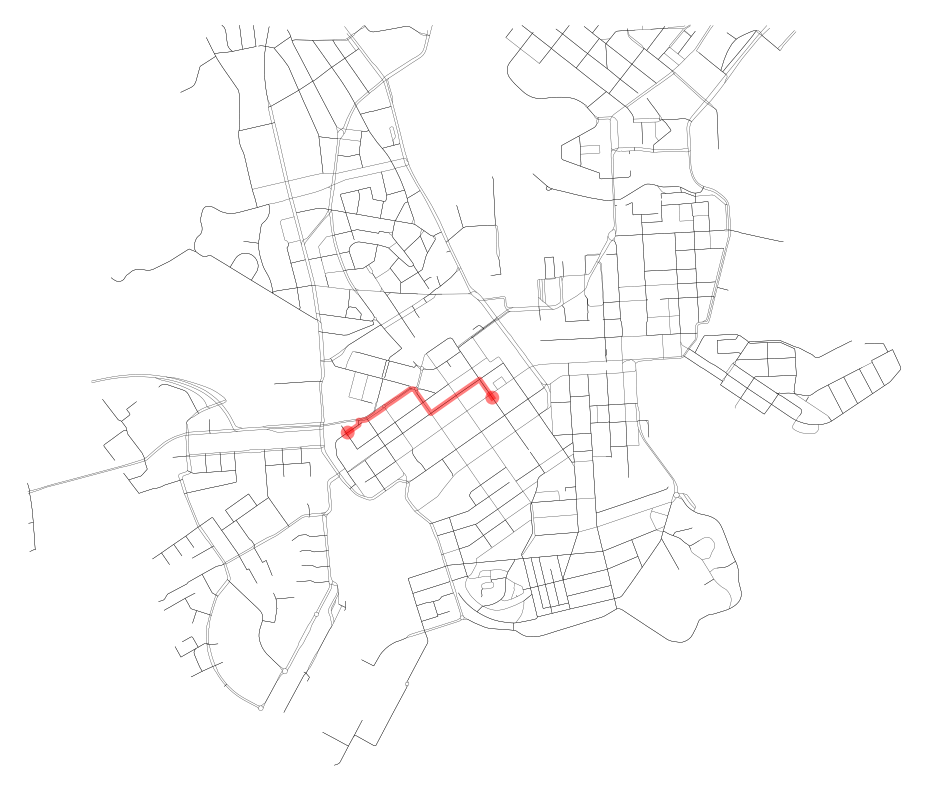

Shortest path distance  1071.5 meters.


In [25]:
# Shortest path based on distance
fig, ax = ox.plot_graph_route(G, metric_path, 
                              edge_linewidth=0.2, node_size=0, bgcolor="white", edge_color="black", figsize=(14,10))

# Print some useful information as well
print(f"Shortest path distance {travel_length: .1f} meters.")

_**Figure 8.X.** The shortest route between the origin and the destination based on distance._


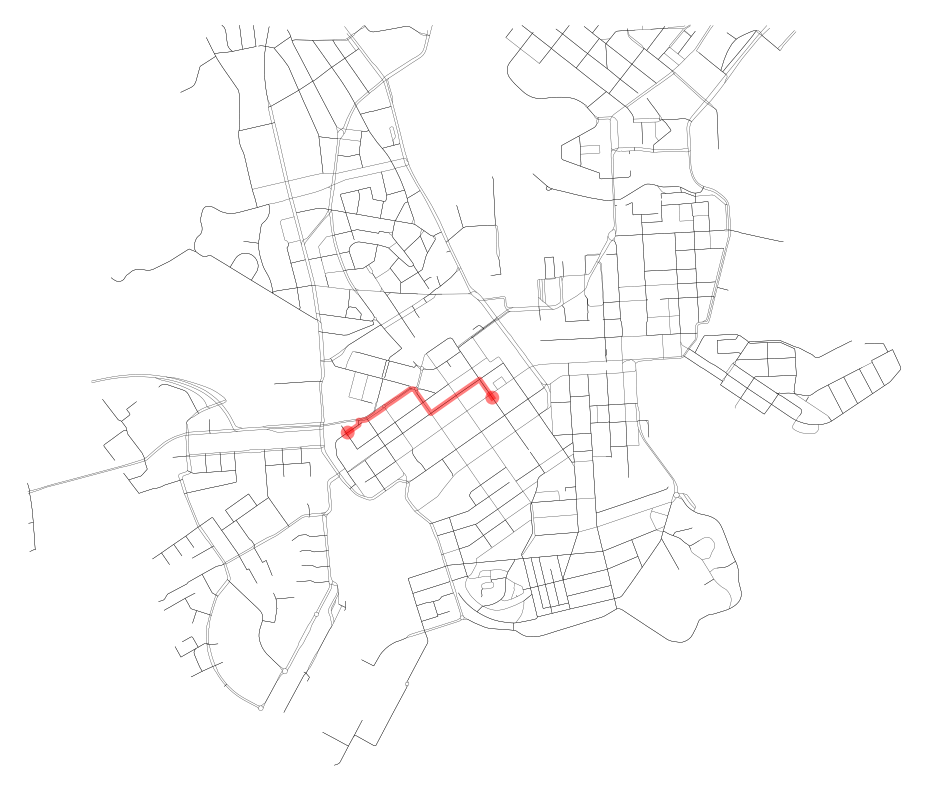

Shortest path time  2.1 minutes.


In [26]:
fig, ax = ox.plot_graph_route(G, time_path,
                             edge_linewidth=0.2, node_size=0, bgcolor="white", edge_color="black", figsize=(14,10))

# Print some useful information as well
print(f"Shortest path time {travel_time/60: .1f} minutes.")


_**Figure 8.X.** The fastest route between the origin and the destination based on travel time._

Great! Now we have successfully found the optimal route between our origin and destination and we also have estimates about the travel time that it takes to travel between the locations by driving. As we can see, the route optimized based on travel time and distance were exactly the same which is natural, as the network here is relatively small and there are no big differences in the speed limits. However, with larger networks, you might get alternating routes as travelling e.g. via ring roads is typically faster than driving throught the city (as an example).

### Summarizing the route

The last step of the basic routing logic that we went through earlier is to retrieve the edge attributes for the given route and summarize them. The route that we got from the `dijkstra_path()` function is a list of visited nodes of the shortest path. Let's take a look at the first nodes of our fastest route:

In [27]:
time_path[:5]

[526728813, 7614374264, 528450748, 149030036, 6572184754]

As we can see, the route is stored as a list of node ids. To find out which streets the route uses, we need to construct the path edges from these nodes by using the `nx.utils.pairwise()` function. This function converts the list of visited nodes into a collection of node-tuples that represent the edges of the shortest path:

In [28]:
path_edges = list(nx.utils.pairwise(time_path))
path_edges[:5]

[(526728813, 7614374264),
 (7614374264, 528450748),
 (528450748, 149030036),
 (149030036, 6572184754),
 (6572184754, 1397071796)]

Using these node pairs, we could look up the attributes of each street segment along the route from our graph. `osmnx` has a handy function `ox.routing.route_to_gdf()` that does this for us and returns the edges of the route as a GeoDataFrame in the order they are traveled. We also pass the same `weight` that we used for finding the route, so that the function picks the same street segments as the routing algorithm did:

In [29]:
route_edges = ox.routing.route_to_gdf(G, time_path, weight="travel_time_seconds")
route_edges[["name", "maxspeed", "length", "travel_time_seconds"]]

,,,name,maxspeed,length,travel_time_seconds
u,v,key,,,,
526728813,7614374264,0,Ruoholahdenkatu,30,47.769063,5.732288
7614374264,528450748,0,Ruoholahdenkatu,30,18.951400,2.274168
528450748,149030036,0,Ruoholahdenkatu,30,7.201292,0.864155
149030036,6572184754,0,Ruoholahdenkatu,30,1.482685,0.177922
6572184754,1397071796,0,Ruoholahdenkatu,30,12.025617,1.443074
...,...,...,...,...,...,...
3228733112,299968946,0,Annankatu,30,2.069238,0.248309
299968946,1377211666,0,Annankatu,30,6.630076,0.795609
1377211666,299968469,0,Annankatu,30,6.562326,0.787479


Now we can see the names of the streets along the route, together with their speed limits, lengths and travel times. Finally, we can summarize the route by calculating the total length and travel time of the trip:

In [30]:
route_edges[["length", "travel_time_seconds"]].sum()

length                 1071.539367
travel_time_seconds     128.584724
dtype: float64

As we can see, the total travel time is the same as the one we calculated earlier with the `dijkstra_path_length()` function. In addition, we now know the total length of the fastest route.

## One-way streets and the direction of travel

In the examples thus far, we have searched the route only to one direction, i.e. from the origin to the destination. However, many trips are made to both directions. A real-life example of these kind of two-way trips is when commuting between home and work locations. Because our graph is directed, traveling to both directions using identical paths is not necessarily possible due to one-way streets. Let's see what happens if we search for the fastest route back from the destination to the origin:

In [31]:
time_path_back = nx.dijkstra_path(
    G, source=dest_node_id, target=orig_node_id, weight="travel_time_seconds"
)
travel_time_back = nx.dijkstra_path_length(
    G, source=dest_node_id, target=orig_node_id, weight="travel_time_seconds"
)

print(f"Travel time to the destination {travel_time/60: .1f} minutes.")
print(f"Travel time back to the origin {travel_time_back/60: .1f} minutes.")

Travel time to the destination  2.1 minutes.
Travel time back to the origin  2.2 minutes.


Let's compare the two routes by plotting them on the same map. For this, we can use the `ox.plot_graph_routes()` function that works in a similar manner as the `ox.plot_graph_route()` function we used earlier, but takes a list of routes as input. We draw the route to the destination with red and the route back to the origin with blue color:

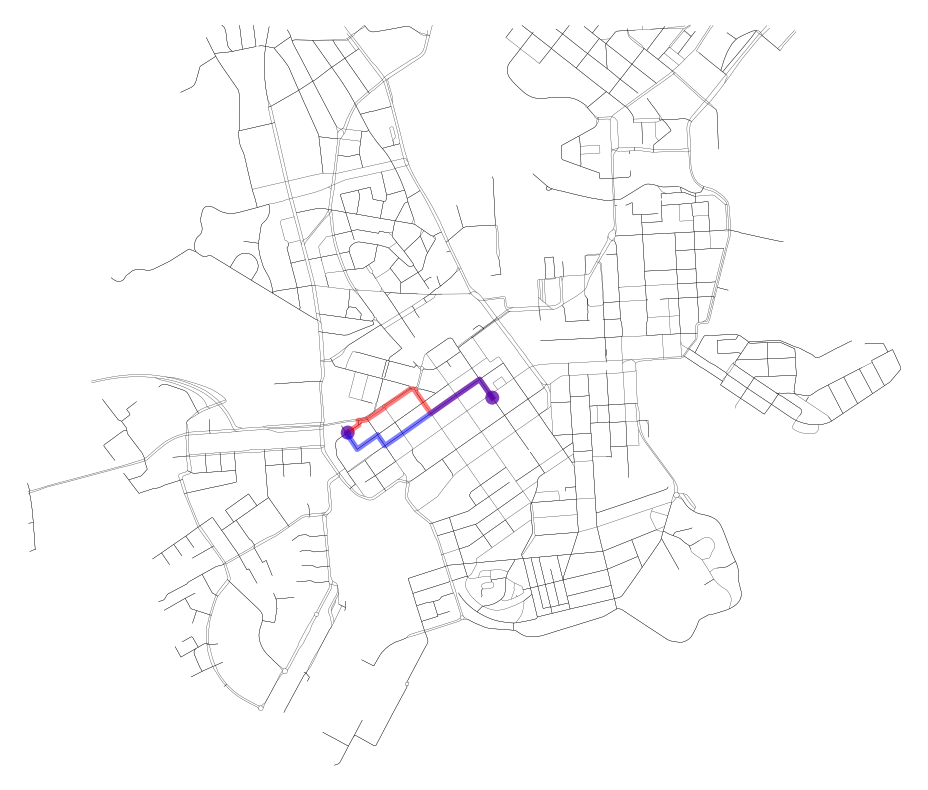

In [32]:
fig, ax = ox.plot_graph_routes(
    G,
    [time_path, time_path_back],
    route_colors=["r", "b"],
    edge_linewidth=0.2,
    node_size=0,
    bgcolor="white",
    edge_color="black",
    figsize=(14, 10),
)

_**Figure 8.X.** The fastest route from the origin to the destination (red) and back from the destination to the origin (blue)._

Where the red and blue routes do not overlap, the route back uses different streets than the route to the destination, because some of the streets along the way can be driven only to one direction. Depending on how long a detour these one-way streets cause, the travel times to the two directions can also differ. With an undirected graph, we could not capture this: the route back could always use the same streets as the route to the destination, and the travel times to both directions would be identical.

## Shortest paths from one origin to many destinations

Thus far, we have searched routes between a single origin and a single destination. However, as we mentioned earlier, the same logic can also be used when calculating one-to-many -type of routing queries. For instance, we might want to know how long it takes to drive from our origin to all other locations in the street network. For this purpose, we can use the `nx.single_source_dijkstra_path_length()` function that calculates the shortest path lengths from a given `source` node to all nodes that can be reached from it:

In [33]:
travel_times = nx.single_source_dijkstra_path_length(
    G, source=orig_node_id, weight="travel_time_seconds"
)
list(travel_times.items())[:5]

[(526728813, 0),
 (1372376935, 0.9220967105638855),
 (6572184736, 1.1101962433349235),
 (6572184737, 1.114981477117969),
 (526728816, 1.8388548344006517)]

As a result, we get a dictionary in which the keys are the ids of the nodes and the values are the travel times (in seconds) from the origin to these nodes. The first item is the origin node itself, which is why its travel time is 0. To see the result on a map, let's add the travel times as a new column to the `nodes` GeoDataFrame that we extracted from the graph earlier. We first convert the dictionary into a `pandas` `Series` that uses the node ids as its index, which makes it possible to match the travel times with the correct nodes. At the same time, we convert the travel times from seconds to minutes:

In [34]:
nodes["travel_time_min"] = pd.Series(travel_times) / 60
nodes[["travel_time_min", "geometry"]].head()

,travel_time_min,geometry
osmid,,
24556474,5.320555,POINT (24.90963 60.18386)
25198796,NaN,POINT (24.90065 60.16698)
25198805,NaN,POINT (24.9032 60.16705)
25198815,1.473700,POINT (24.90869 60.16657)
25198820,NaN,POINT (24.90803 60.16657)


Nodes that cannot be reached from the origin get a missing value (`NaN`), because they do not have a travel time in the result. Now we can visualize the travel times on a map. Here, we first plot the streets with light gray color as a background and then plot the nodes on top of them, colored by the travel time:

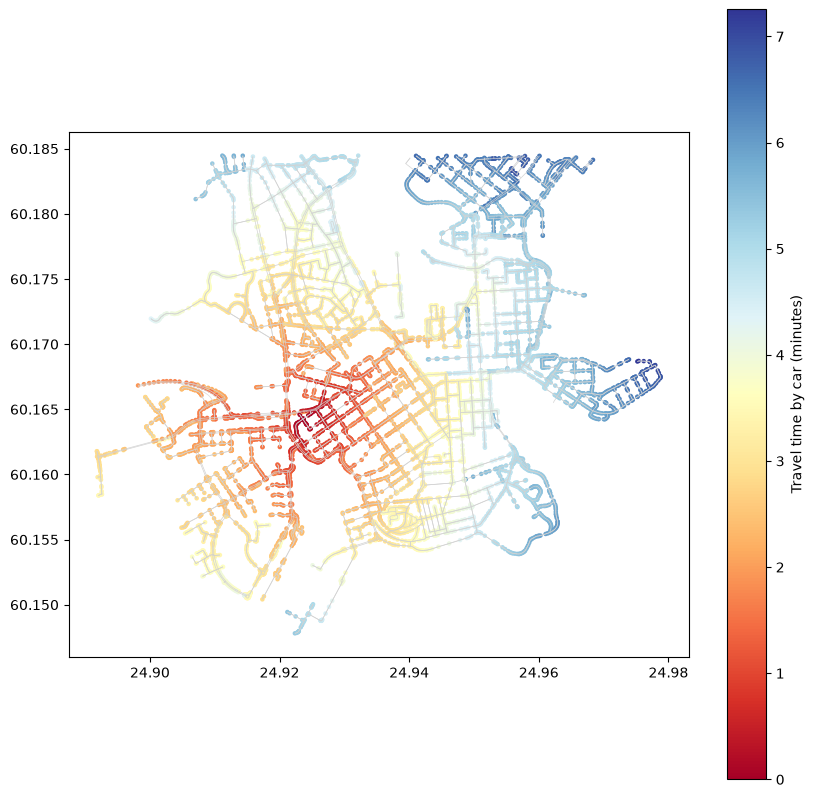

In [35]:
ax = edges.plot(color="lightgrey", linewidth=0.5, figsize=(10, 10))
ax = nodes.plot(
    ax=ax,
    column="travel_time_min",
    cmap="RdYlBu",
    markersize=5,
    legend=True,
    legend_kwds={"label": "Travel time by car (minutes)"},
)

_**Figure 8.X.** Travel time by car (in minutes) from the origin to all nodes in the street network._

As we can see, the travel times generally increase the further away the nodes are from the origin. Calculating travel times from one or many origins to all destinations like this is the basis of accessibility analysis, which we will discuss in more detail in Chapter 11.

In this section, we learned how to retrieve a street network from OpenStreetMap, prepare it for routing by calculating travel times for the streets, and use it for finding the shortest paths between locations. However, routing is only one of the many things that we can do with networks. In the next section, we will look at other common network operations, such as identifying the connected components of a network and measuring the centrality of its nodes and edges.

## Footnotes

[^networkx]: <https://networkx.github.io/documentation/stable/>
[^dijkstra]: <https://networkx.github.io/documentation/networkx-1.10/reference/generated/networkx.algorithms.shortest_paths.weighted.single_source_dijkstra.html>
[^astar]: <https://networkx.github.io/documentation/networkx-1.10/reference/generated/networkx.algorithms.shortest_paths.astar.astar_path.html>
[^osmnx]: <https://osmnx.readthedocs.io/en/stable/>
[^ykr]: <https://www.avoindata.fi/data/fi/dataset/kaupunki-maaseutu-luokitus-ykr>
[^dijkstra_algorithm]: <https://en.wikipedia.org/wiki/Dijkstra%27s_algorithm>
